In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
#ライブラリ読み込み
import pandas as pd
import numpy as np
import lightgbm as lgb

import glob
import os
import re

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

In [3]:
#データ読み込み
df_train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df_test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [4]:
#データ確認
display(df_train.head())
print(df_train.shape)

display(df_test.head())
print(df_test.shape)

df_train.info()
df_test.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


(891, 12)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


(418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1 

In [5]:
#欠損確認
print(df_train.isnull().sum())
print(df_test.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [6]:
#Embarked,Fareの欠損処理
median_fare = df_train["Fare"].median()

df_train["Fare"] = df_train["Fare"].fillna(median_fare)
df_test["Fare"]  = df_test["Fare"].fillna(median_fare)

mode_embarked = df_train["Embarked"].mode()[0]

df_train["Embarked"] = df_train["Embarked"].fillna(mode_embarked)
df_test["Embarked"]  = df_test["Embarked"].fillna(mode_embarked)

In [7]:
#df_train testのコピー作成
#Age,Cabinの欠損部分を把握するため
df_train_raw = df_train.copy()
df_test_raw = df_test.copy()

In [8]:
#Ageの欠損処理
#Ageの欠損は記入漏れによるものなので中央値で埋める
df_train["Age"] = df_train.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df_test["Age"]  = df_test.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))

In [9]:
#Cabinの欠損処理
#Cabinの欠損は7割に及ぶので列ごと削除
df_train = df_train.drop(columns=["Cabin"])
df_test  = df_test.drop(columns=["Cabin"])

In [10]:
#特徴量を追加
df_train["FamilySize"] = df_train["SibSp"] + df_train["Parch"] + 1
df_test["FamilySize"] = df_test["SibSp"] + df_test["Parch"] + 1

df_train["TicketGroup"] = df_train_raw.groupby("Ticket")["Ticket"].transform("count")
df_test["TicketGroup"] = df_test_raw.groupby("Ticket")["Ticket"].transform("count")

df_train["Deck"] = df_train_raw["Cabin"].str[0].fillna("U").astype("category")
df_test["Deck"] = df_test_raw["Cabin"].str[0].fillna("U").astype("category")

In [11]:
#Nameを分類する関数を定義
def extract_title(df):
    df = df.copy()
    df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")

    df["Title"] = df["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs",
    })

    officer = ["Col", "Major", "Capt"]
    royalty = ["Lady", "Sir", "Countess"]

    df["Title"] = df["Title"].apply(
        lambda x:
            "Officer" if x in officer else
            "Royalty" if x in royalty else
            "Dr" if x == "Dr" else
            "Rev" if x == "Rev" else
            x if x in ["Mr", "Mrs", "Miss", "Master"] else
            "Common"
    )
    return df

In [12]:
#実行
df_train["Title"] = extract_title(df_train_raw)["Title"]
df_test["Title"]  = extract_title(df_test_raw)["Title"]

In [13]:
#不要列の削除
df_train = df_train.drop(columns=["Name", "Ticket"])
df_test  = df_test.drop(columns=["Name", "Ticket"])

In [14]:
#データセットを作成
x_train = df_train.drop(columns=["Survived", "PassengerId"])
y_train = df_train["Survived"]
id_train = df_train["PassengerId"]

x_test = df_test.drop(columns=["PassengerId"])
id_test = df_test["PassengerId"]

for col in ["Sex", "Embarked", "Title"]:
    x_train[col] = x_train[col].astype("category")
    x_test[col]  = x_test[col].astype("category")

print(x_train.shape, y_train.shape, id_train.shape)

(891, 11) (891,) (891,)


In [15]:
#run名を決める補助関数

BASE_DIR = "/kaggle/working/runs"

def get_next_run_name(base_dir=BASE_DIR):
    os.makedirs(base_dir, exist_ok=True)

    runs = [d for d in os.listdir(base_dir) if re.match(r"run\d+", d)]

    if not runs:
        return "run0"

    nums = [int(re.search(r"run(\d+)", r).group(1)) for r in runs]
    next_id = max(nums) + 1

    return f"run{next_id}"

In [16]:
#学習関数

def train_lgb(input_x, input_y, params, n_splits=5, run_name="run0"):

    # --- run ごとの保存フォルダ ---
    save_dir = f"{BASE_DIR}/{run_name}"
    os.makedirs(save_dir, exist_ok=True)
    

    metrics = []
    imp = pd.DataFrame()
    oof = np.zeros(len(input_x))

    cv = list(StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123).split(input_x, input_y))

    for nfold in range(n_splits):
        idx_tr, idx_va = cv[nfold]
        x_tr, y_tr = input_x.iloc[idx_tr, :], input_y.iloc[idx_tr]
        x_va, y_va = input_x.iloc[idx_va, :], input_y.iloc[idx_va]

        model = lgb.LGBMClassifier(**params)

        model.fit(
            x_tr, y_tr,
            eval_set=[(x_tr, y_tr), (x_va, y_va)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
            ],
        )

        # --- run ごとにモデル保存 ---
        model.booster_.save_model(f"{save_dir}/model_fold{nfold}.txt")

        # AUC 用の確率予測
        y_tr_pred = model.predict_proba(x_tr)[:, 1]
        y_va_pred = model.predict_proba(x_va)[:, 1]

        auc_tr = roc_auc_score(y_tr, y_tr_pred)
        auc_va = roc_auc_score(y_va, y_va_pred)

        metrics.append([nfold, auc_tr, auc_va])

        oof[idx_va] = y_va_pred

        _imp = pd.DataFrame({
            "col": input_x.columns,
            "imp": model.feature_importances_,
            "nfold": nfold
        })
        imp = pd.concat([imp, _imp], axis=0, ignore_index=True)

    metrics = np.array(metrics)

    cv_tr_mean = metrics[:,1].mean()
    cv_tr_std  = metrics[:,1].std()
    cv_va_mean = metrics[:,2].mean()
    cv_va_std  = metrics[:,2].std()

    oof_auc = roc_auc_score(input_y, oof)

    print("-"*20, f"result ({run_name})", "-"*20)
    print("[cv ] tr: {:.4f}+-{:.4f}, va: {:.4f}+-{:.4f}".format(
        cv_tr_mean, cv_tr_std,
        cv_va_mean, cv_va_std,
    ))
    print("[oof] {:.4f}".format(oof_auc))

    imp = imp.groupby("col")["imp"].agg(["mean", "std"]).reset_index()
    imp.columns = ["col", "imp", "imp_std"]

    log_text = (
        f"run: {run_name}\n"
        f"CV AUC_tr: {cv_tr_mean:.5f} ± {cv_tr_std:.5f}\n"
        f"CV AUC_va: {cv_va_mean:.5f} ± {cv_va_std:.5f}\n"
        f"OOF AUC: {oof_auc:.5f}"
    )

    # --- log_text も run ごとに保存 ---
    with open(f"{save_dir}/history.txt", "w") as f:
        f.write(log_text)

    return imp, metrics, oof, log_text

In [17]:
#log解析関数

def parse_log(text):
    tr = re.search(r"CV AUC_tr: ([0-9.]+)", text)
    va = re.search(r"CV AUC_va: ([0-9.]+)", text)
    oof_match = re.search(r"OOF AUC: ([0-9.]+)", text)

    tr = float(tr.group(1)) if tr else None
    va = float(va.group(1)) if va else None
    oof_auc = float(oof_match.group(1)) if oof_match else None

    return tr, va, oof_auc

In [18]:
#パラメータ
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary', 
    'metric': 'auc',
    'learning_rate': 0.1,
    'num_leaves': 16,
    'n_estimators': 5000,
    "random_state": 123,
    "importance_type": "gain",
}    

In [19]:
#学習実行
run_name = get_next_run_name()
imp, metrics, oof, log_text = train_lgb(x_train, y_train, params, run_name=run_name)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 241
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Info] Number of positive: 274, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 241
[LightGBM] [Info] Number of data points in the train set: 713, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.384292 -> initscore=-0.471371
[LightGBM] [Info

In [20]:
#学習結果をdataframe化

results = []

for path in sorted(glob.glob("/kaggle/working/runs/run*/history.txt")):
    text = open(path).read()
    tr, va, oof_auc = parse_log(text)
    results.append([path, tr, va, oof_auc])

results_df = pd.DataFrame(results, columns=["run", "AUC_tr", "AUC_va", "AUC_oof"])
results_df["run"] = results_df["run"].apply(lambda x: os.path.basename(os.path.dirname(x)))

display(results_df)

,run,AUC_tr,AUC_va,AUC_oof
0,run0,0.96698,0.88568,0.881


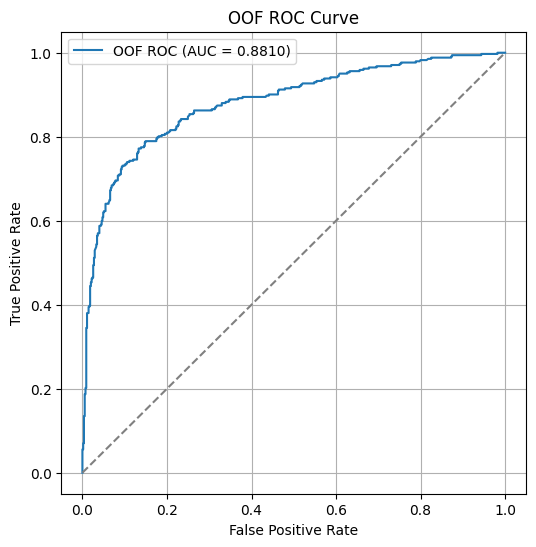

In [21]:
#oof全体のroc曲線

fpr, tpr, _ = roc_curve(y_train, oof)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"OOF ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("OOF ROC Curve")
plt.legend()
plt.grid()
plt.show()

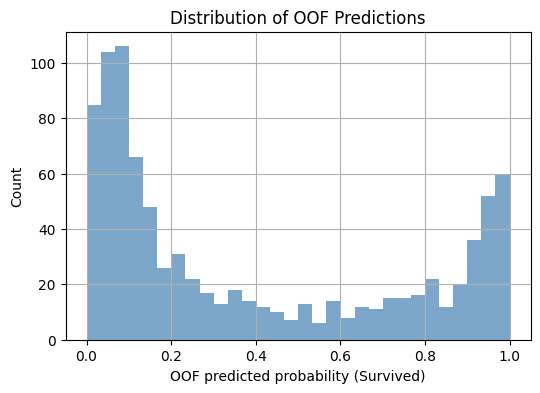

In [22]:
#oofの予測分布

plt.figure(figsize=(6, 4))
plt.hist(oof, bins=30, alpha=0.7, color="steelblue")
plt.xlabel("OOF predicted probability (Survived)")
plt.ylabel("Count")
plt.title("Distribution of OOF Predictions")
plt.grid()
plt.show()

In [23]:
#imp確認
imp.sort_values("imp", ascending=False, ignore_index=True)

,col,imp,imp_std
0,Sex,1039.404145,141.980760
1,Age,584.033451,167.773988
2,Fare,582.879417,220.042264
3,Pclass,366.003840,56.141675
4,Title,183.659069,119.622609
5,FamilySize,120.193382,36.361351
6,TicketGroup,109.552260,46.324492
7,Embarked,68.451246,54.221685
8,SibSp,40.933085,29.527767
9,Deck,37.868569,14.085647


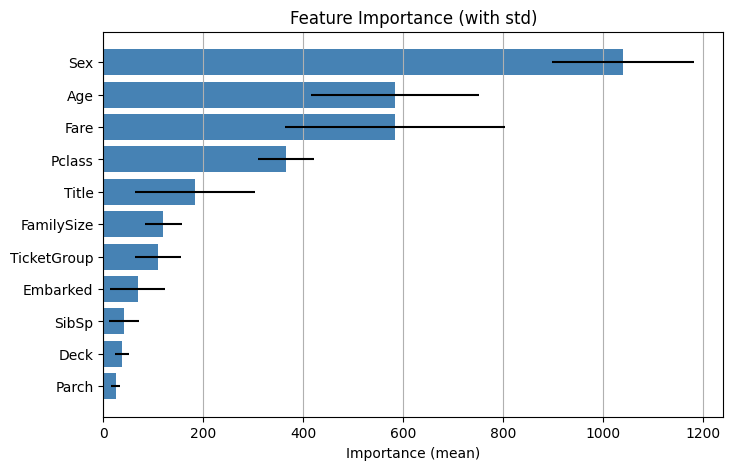

In [24]:
#特徴量重要度を可視化

imp_sorted = imp.sort_values("imp", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(imp_sorted["col"], imp_sorted["imp"], xerr=imp_sorted["imp_std"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importance (mean)")
plt.title("Feature Importance (with std)")
plt.grid(axis="x")
plt.show()


In [25]:
#推論関数
def predict_lgb(input_x,
                input_id,
                run_name,
                list_nfold=[0,1,2,3,4]):
    
    model_dir = f"/kaggle/working/runs/{run_name}"
    
    pred = np.zeros((len(input_x), len(list_nfold)))
    
    for nfold in list_nfold:
        print("-"*20, f"fold {nfold}", "-"*20)
        
        # ★ LightGBM のテキストモデルを読み込む
        fname_lgb = f"{model_dir}/model_fold{nfold}.txt"
        model = lgb.Booster(model_file=fname_lgb)
        
        # LightGBM Booster の predict
        pred[:, nfold] = model.predict(input_x)
    
    pred_mean = pred.mean(axis=1)
    
    pred_df = pd.concat([
        input_id.reset_index(drop=True),
        pd.DataFrame({"pred": pred_mean})
    ], axis=1)
    
    print("Done.")
    return pred_df

In [26]:
#推論実行
pred_df = predict_lgb(
    input_x=x_test,
    input_id=id_test,
    run_name="run0"
)

-------------------- fold 0 --------------------
-------------------- fold 1 --------------------
-------------------- fold 2 --------------------
-------------------- fold 3 --------------------
-------------------- fold 4 --------------------
Done.


In [27]:
#提出ファイルの作成
submission = pred_df.copy()
submission["Survived"] = (submission["pred"] > 0.5).astype(int)
submission = submission[["PassengerId", "Survived"]]
submission.to_csv("submission.csv", index=False)

In [28]:
#ファイル出力
print(submission.shape)
display(submission.head())

(418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
